## Data cleaning and exploration at scale

This script reads web archive files from a folder and extracts the main text from each web page. Here I use the readability library and BeautifulSoup to find the important content. 

In this code snippet I prepare data for all of my projects: Word Count, Markov Chains and Word Day Burst. 
For the Word Day Burst I also exatract the exact date and skip words which are shorter then 4 characters (to skip "the", "der/die/das" etc.)

I noticed, that some pages dont allow web scraping and are therefore not suitable for the project. So for the Quality Control I skip pages that mention "javascript" or "js" and ignore very short texts (less than 10 words).

Also, running this task without parallelisation took too much time, so I had to run it on another machine while using ray.

On my device I got an Out of Memory error, no matter how I changed the parameters.

In [ ]:
import ray
import os
from datetime import datetime
from warcio.archiveiterator import ArchiveIterator
from bs4 import BeautifulSoup
from readability.readability import Document
import json
from collections import defaultdict
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
if not ray.is_initialized():
    ray.init(
        ignore_reinit_error=True,
        object_store_memory=4 * 1024 * 1024 * 1024,
        _memory=4 * 1024 * 1024 * 1024
    )

FOLDER = 'crawl1'
MIN_WORD_LENGTH = 3

def extract_main_text(html_bytes):
    try:
        html = html_bytes.decode('utf-8', errors='ignore')
        if not html or len(html) < 50:
            return ""
        doc = Document(html)
        summary = doc.summary()
        if not summary:
            return ""
        soup = BeautifulSoup(summary, 'html.parser')
        return soup.get_text(separator=' ', strip=True)
    except Exception:
        return ""

@ray.remote
def process_warc_file(filepath):
    local_text_chunks = []
    local_date_word_data = []
    
    try:
        with open(filepath, 'rb') as stream:
            for record in ArchiveIterator(stream):
                if record.rec_type == 'response':
                    date_str = record.rec_headers.get_header('WARC-Date')
                    date_key = None
                    if date_str:
                        try:
                            date = datetime.fromisoformat(date_str.replace('Z', '+00:00')).date()
                            date_key = str(date)
                        except:
                            pass
                    
                    html_bytes = record.content_stream().read()
                    text = extract_main_text(html_bytes)
                    
                    if "javascript" in text.lower() or "js" in text.lower():
                        continue
                    
                    if text and len(text.split()) > 10:
                        local_text_chunks.append(text)
                        
                        if date_key:
                            words = [w for w in text.lower().split() if len(w) >= MIN_WORD_LENGTH]
                            if words:
                                local_date_word_data.append((date_key, words))
    except Exception as e:
        print(f"Error with file {filepath}: {e}")
    
    return local_text_chunks, local_date_word_data

filepaths = [
    os.path.join(FOLDER, f)
    for f in os.listdir(FOLDER)
    if os.path.isfile(os.path.join(FOLDER, f))
]


BATCH_SIZE = 3 
text_chunks = []
date_word_data = []

for i in range(0, len(filepaths), BATCH_SIZE):
    batch = filepaths[i:i + BATCH_SIZE]

    tasks = [process_warc_file.remote(fp) for fp in batch]
    results = ray.get(tasks)

    for text_list, date_word_list in results:
        text_chunks.extend(text_list)
        date_word_data.extend(date_word_list)

with open('extracted_data.json', 'w', encoding='utf-8') as f:
    json.dump({
        'text_chunks': text_chunks,
        'date_word_data': date_word_data
    }, f, indent=2, ensure_ascii=False)

## Word Count

Here I count words per file & the total amount

In [ ]:
if not ray.is_initialized():
    ray.init(
        ignore_reinit_error=True,
        object_store_memory= 2 * 1024 * 1024 * 1024,
        _memory= 2 * 1024 * 1024 * 1024
    )
    
@ray.remote
def count_words_in_file(filepath):
    count = 0
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            count += len(line.split())
    return count


folder = 'crawl1'
filepaths = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if os.path.isfile(os.path.join(folder, f))
]

tasks = [count_words_in_file.remote(fp) for fp in filepaths]

word_counts = ray.get(tasks)

print(f"Words per file: {word_counts}")
print(f"All words: {sum(word_counts)}")

Words per file: [17260416, 18099614, 12943488, 17028448, 15984991, 16407879, 15760534, 16542485, 15279433, 10179338, 16133256, 14987556, 16300702, 16041047, 9841723, 17040592, 18001649, 15195338, 15171004, 9661931, 9959266, 16789414, 10402358, 16766329, 13900445, 8790884, 15907990, 8674758, 10245218, 9435368, 15626815]
All words: 440360269


## Markov Chains

I won't be using ray in this or the next project. I tried doing it multiple times, but my programme crashed every time with an Out of Memory error, no matter how I changed the parameters. As reading data in multiple batches or allocating very little memory to the ray would not improve performance significantly for this task, I decided to use the normal script. 


This code:
1. reads text chunks
2. learns which words commonly follow each pair of words
3. generates new text by randomly picking the next word based on these word pairs

In [ ]:
with open('extracted_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
    text_chunks = data['text_chunks']

MARKOV_ORDER = 2


transitions = defaultdict(list)


for idx, text in enumerate(text_chunks):

    if not text:
        continue
    
    words = text.split()
    if len(words) < MARKOV_ORDER + 1:
        continue
    
    for i in range(len(words) - MARKOV_ORDER):
        state = tuple(words[i:i + MARKOV_ORDER])
        next_word = words[i + MARKOV_ORDER]
        transitions[state].append(next_word)

transitions = dict(transitions)




def generate_text(transitions, order, num_words=100, seed=None):
    if seed:
        random.seed(seed)
    
    current_state = random.choice(list(transitions.keys()))
    result = list(current_state)
    
    for _ in range(num_words - order):
        if current_state not in transitions:
            current_state = random.choice(list(transitions.keys()))
            continue
        
        next_word = random.choice(transitions[current_state])
        result.append(next_word)
        current_state = tuple(result[-order:])
    
    return ' '.join(result)


print("Markov chain text: ", generate_text(transitions, MARKOV_ORDER, num_words=100))

Markov chain text:  Zukunft allein bei den Abstimmungen am Mittwoch. Nach Durows Verhaftung: Telegram gab mehr als 15.000 Menschen protestieren in Wien hielten Schilder und Transparente mit strafbarem Inhalt. Die scheidende US-Regierung eine Rolle spielen, ob Antisemitismus politisch motiviert Den Anwälten des Kremlgegners wird die Bundestagsdebatte zum Zustrombegrenzungsgesetz soll nun im Recht Amazon sieht sich jedoch kaum erfüllen. Schon, weil sich ein anderes Gebiet in Cherson +++ Bei den Importen gab es diesmal klappen könnte, Frau Machikawa? «Ich hätte mir geholfen. Hier bin ich gewöhnt", sagt Baerbock. Es gebe jedoch Möglichkeiten, beides miteinander zu leben. An jenem 20. Januar frei seien, werde die


#### More examples:

In [8]:

print("Markov chain text: ", generate_text(transitions, MARKOV_ORDER, num_words=50))

Markov chain text:  Kleinbus am Samstag erstmals in New Orleans, Louisiana. The neighbor who lives in Doodle House, a London-based head hunter. To any millennials (and others) covering pop songs. Marry Waterson makes the case saying: 'Seeking to argue how football works. Guardiola will keep the individual brilliance the only liquid he could


In [9]:

print("Markov chain text: ", generate_text(transitions, MARKOV_ORDER, num_words=20))

Markov chain text:  donation stood at almost five million were supposed to go to A.A.; to seek a pardon on Monday. Couples wanting


## Word Burst

This code: 
1. retrieves word data by date
2. counts how often each word appears each day
3. calculates the average daily usage of each word
4. identifies days on which a word is used at least twice as frequently as usual 
5. prints the top bursty words for each of the first ten days

Here I excluded all the numbers and dates (like YYYY.MM.DD), as I dont find it interesting in this context.

In [ ]:
with open('extracted_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
    date_word_data = data['date_word_data']


BURST = 2.0

# count words per date
date_word_counts = defaultdict(lambda: defaultdict(int))

for idx, (date, words) in enumerate(date_word_data):
    for word in words:

        if word.replace(".", "").isdigit():
            continue
        

        date_word_counts[date][word] += 1

date_word_counts = {date: dict(counts) for date, counts in date_word_counts.items()}

word_totals = defaultdict(int)
word_days = defaultdict(int)



# total uses for each word
for date, word_counts in date_word_counts.items():
    for word, count in word_counts.items():
        word_totals[word] += count
        word_days[word] += 1


# average uses per day
word_avg = {w: word_totals[w] / word_days[w] for w in word_totals}

bursts = defaultdict(list)


# find bursts
for date, word_counts in date_word_counts.items():
    for word, count in word_counts.items():
        avg = word_avg[word]
        if count >= BURST * avg:
            bursts[date].append({'word': word, 'count': count, 'avg': avg, 'ratio': count / avg})
    
    # sort bursts in descending order 
    bursts[date].sort(key=lambda x: x['ratio'], reverse=True)

bursts = dict(bursts)



sorted_dates = sorted(bursts.keys())
top_10_dates = sorted_dates[:10]

for date in top_10_dates:
    print(f"\n{date}")
    print("-" * 60)
    
    top_bursts = bursts[date][:5]
    
    for rank, burst in enumerate(top_bursts, start=1):
        word = burst['word']
        count = burst['count']
        avg = burst['avg']
        ratio = burst['ratio']
        
        print(f"{rank:2d}. '{word:15s}' - {count:4d} times (on average: {avg:5.1f}) = {ratio:.1f}x more often")


2025-01-01
------------------------------------------------------------
   1. 'feuerwerk      ' -  446 times (on average:  35.9) = 12.4x more often
   2. 'böller         ' -  247 times (on average:  20.5) = 12.1x more often
   3. 'menschenmenge  ' -  211 times (on average:  17.7) = 12.0x more often
   4. 'neujahrsansprache' -  120 times (on average:  10.0) = 11.9x more often
   5. 'freies         ' -   69 times (on average:   5.8) = 11.8x more often

2025-01-02
------------------------------------------------------------
   1. 'medienberichte ' -  138 times (on average:   8.6) = 16.0x more often
   2. 'nikolaus       ' -  112 times (on average:   7.6) = 14.7x more often
   3. 'cybertruck     ' -  501 times (on average:  37.1) = 13.5x more often
   4. 'bildungseinrichtungen' -   78 times (on average:   6.1) = 12.7x more often
   5. 'montenegro     ' -   93 times (on average:   7.4) = 12.6x more often

2025-01-03
------------------------------------------------------------
   1. 'ampel-

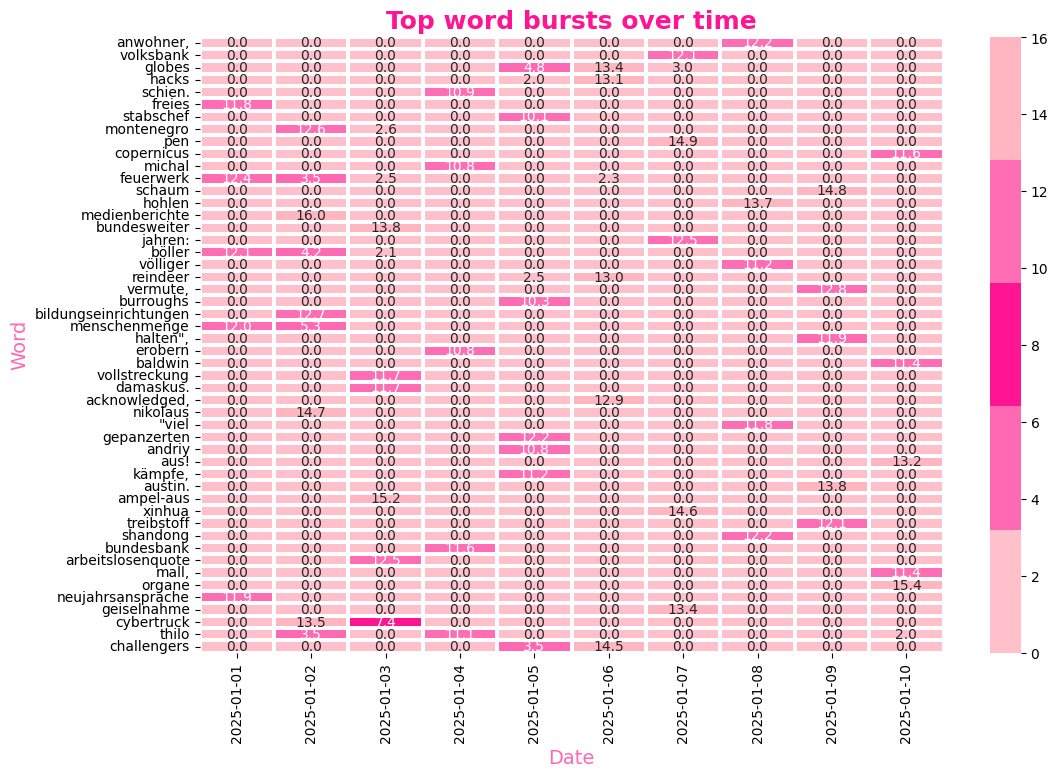

In [ ]:
# top words across all top dates
top_words = set()
for date in top_10_dates:
    top_words.update([b['word'] for b in bursts[date][:5]])
top_words = list(top_words)

# heatmap 
matrix = []
for word in top_words:
    row = []
    for date in top_10_dates:
        found = next((b['ratio'] for b in bursts[date] if b['word'] == word), 0)
        row.append(found)
    matrix.append(row)

matrix = np.array(matrix)

plt.figure(figsize=(12, 8))


# my barbie color palette 
pink_palette = sns.color_palette(["#FFC0CB", "#FF69B4","#FF1493","#FF6EB4", "#FFB6C1"])

sns.heatmap(matrix, annot=True, fmt=".1f",xticklabels=top_10_dates, yticklabels=top_words, cmap=pink_palette, linewidths=1.5, linecolor='white')

plt.title("Top word bursts over time", fontsize=18, color="#FF1493", fontweight='bold')
plt.xlabel("Date", fontsize=14, color="#FF69B4")
plt.ylabel("Word", fontsize=14, color="#FF69B4")
plt.show()


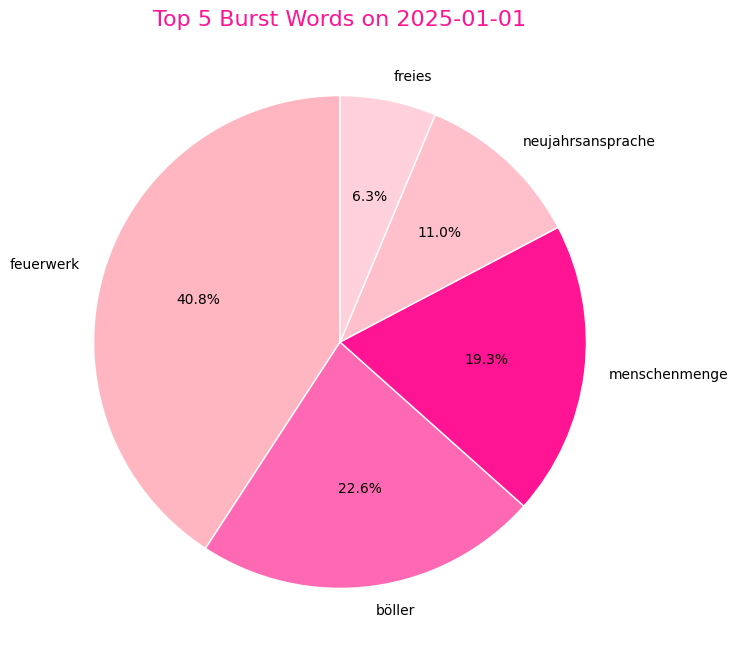

In [ ]:
date_to_plot = top_10_dates[0]
top_bursts = bursts[date_to_plot][:5]

words = [burst['word'] for burst in top_bursts]
counts = [burst['count'] for burst in top_bursts]

colors = ['#FFB6C1', '#FF69B4', '#FF1493', '#FFC0CB', '#FFD1DC']

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=words, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor':'white'})
plt.title(f"Top 5 words on {date_to_plot}", color="#FF1493", fontsize=16)
plt.show()
